# 词嵌入

## 1. Skip-gram

从零开始实现一个简单的Skip-gram,语料库使用《爱丽丝梦游仙境》(Alice's Adventures in Wonderland) 的开篇片段。

### 第一步：加载与清洗数据 (Data Preprocessing)

我们要写一个清洗函数。这在 NLP 中叫做 Tokenization (分词) 和 Normalization (标准化)。

In [ ]:
import torch
import re
import torch.optim as optim
from torch import nn
from collections import Counter

# ============================================================
# 1. 定义语料库
# ============================================================
# 使用《爱丽丝梦游仙境》的开篇片段作为训练数据
# 在真实应用中，通常需要更大规模的语料库（如维基百科、新闻文章等）
raw_text = """
Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, 'and what is the use of a book,' thought Alice 'without pictures or conversation?'
So she was considering in her own mind (as well as she could, for the hot day made her feel very sleepy and stupid), whether the pleasure of making a daisy-chain would be worth the trouble of getting up and picking the daisies, when suddenly a White Rabbit with pink eyes ran close by her.
There was nothing so very remarkable in that; nor did Alice think it so very much out of the way to hear the Rabbit say to itself, 'Oh dear! Oh dear! I shall be too late!' (when she thought it over afterwards, it occurred to her that she ought to have wondered at this, but at the time it all seemed quite natural); but when the Rabbit actually took a watch out of its waistcoat-pocket, and looked at it, and then hurried on, Alice started to her feet, for it flashed across her mind that she had never before seen a rabbit with either a waistcoat-pocket, or a watch to take out of it, and burning with curiosity, she ran across the field after it, and fortunately was just in time to see it pop down a large rabbit-hole under the hedge.
"""

# ============================================================
# 2. 定义停用词 (Stopwords)
# ============================================================
# 停用词：出现频率很高但对语义贡献较少的词，如 "the", "a", "is" 等
# 移除停用词可以：
#   - 减少词表大小，降低计算复杂度
#   - 让模型更专注于有意义的词汇关系
# 在实际工程中，通常使用 NLTK 或 spaCy 库的停用词表
stop_words = set(['the', 'of', 'and', 'a', 'to', 'in', 'was', 'it', 
                  'that', 'she', 'her', 'as', 'for', 'with', 'on', 'at',
                  'by', 'but', 'is', 'had', 'not', 'be', 'so', 'very', 'or'])

def preprocess_text(text):
    """文本预处理函数
    
    执行步骤：
    1. 转换为小写：统一大小写，避免 "Alice" 和 "alice" 被视为不同词
    2. 去除标点符号：简化处理，只保留字母和空格
    3. 分词：按空格分割成单词列表
    4. 去除停用词：过滤掉高频但无意义的词
    
    参数:
        text: 原始文本字符串
        
    返回:
        words: 清洗后的单词列表
    """
    # 步骤1: 将文本转换为小写
    text = text.lower()
    
    # 步骤2: 去除标点符号
    # [^\w\s] 表示匹配所有非字母、非数字、非空格的字符
    text = re.sub(r'[^\w\s]', '', text)
    
    # 步骤3: 分词（按空格分割）
    words = text.split()
    
    # 步骤4: 去除停用词
    # 列表推导式：只保留不在停用词集合中的单词
    words = [word for word in words if word not in stop_words]
    
    return words

# 执行预处理
processed_words = preprocess_text(raw_text)
print("Processed Words: \n", processed_words)


Processed Words: 
 ['alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'having', 'nothing', 'do', 'once', 'twice', 'peeped', 'into', 'book', 'sister', 'reading', 'no', 'pictures', 'conversations', 'what', 'use', 'book', 'thought', 'alice', 'without', 'pictures', 'conversation', 'considering', 'own', 'mind', 'well', 'could', 'hot', 'day', 'made', 'feel', 'sleepy', 'stupid', 'whether', 'pleasure', 'making', 'daisychain', 'would', 'worth', 'trouble', 'getting', 'up', 'picking', 'daisies', 'when', 'suddenly', 'white', 'rabbit', 'pink', 'eyes', 'ran', 'close', 'there', 'nothing', 'remarkable', 'nor', 'did', 'alice', 'think', 'much', 'out', 'way', 'hear', 'rabbit', 'say', 'itself', 'oh', 'dear', 'oh', 'dear', 'i', 'shall', 'too', 'late', 'when', 'thought', 'over', 'afterwards', 'occurred', 'ought', 'have', 'wondered', 'this', 'time', 'all', 'seemed', 'quite', 'natural', 'when', 'rabbit', 'actually', 'took', 'watch', 'out', 'its', 'waistcoatpocket', 'looked', 'then', 'hurried'

In [ ]:
# ============================================================
# 构建词表 (Vocabulary)
# ============================================================
# 词表：将文本中的每个唯一单词映射到一个唯一的整数索引
# 神经网络无法直接处理文本，需要将词转换为数字

# 步骤1: 去重，获取所有唯一的单词
vocab = set(processed_words)

# 步骤2: 创建词 -> 索引 的映射字典
# 如: {'alice': 0, 'beginning': 1, 'get': 2, ...}
word_to_idx = {word: i for i, word in enumerate(vocab)}

# 步骤3: 创建索引 -> 词 的映射字典（反向映射，用于结果查看）
# 如: {0: 'alice', 1: 'beginning', 2: 'get', ...}
idx_to_word = {i: word for i, word in enumerate(vocab)}

# 步骤4: 获取词表大小（有多少个不同的词）
vocab_size = len(vocab)

# 打印统计信息
print(f"原始单词数: {len(raw_text.split())}")  # 包含重复和停用词
print(f"清洗后单词数: {len(processed_words)}")  # 去除停用词后
print(f"词表大小 (去重): {vocab_size}")  # 唯一单词数量
print("前10个有效单词:", processed_words[:10])


原始单词数: 254
清洗后单词数: 136
词表大小 (去重): 113
前10个有效单词: ['alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'having', 'nothing', 'do']


### 第二步：生成训练对 (Training Pairs)

这是 Skip-gram 的灵魂。我们要生成 (中心词, 上下文词) 的配对。

我们假设窗口大小为2。

In [ ]:
# ============================================================
# 生成 Skip-gram 训练对
# ============================================================
# Skip-gram 的核心思想：通过中心词预测周围的上下文词
# 例如："alice beginning get tired" 中，如果窗口大小为2：
#   中心词="get" -> 上下文词可能是: "alice", "beginning", "tired"

window_size = 2  # 窗口大小：查看中心词左右各2个词
skipgram_pairs = []  # 存储 (中心词索引, 上下文词索引) 对

# 遍历语料库中的每个词作为中心词
for i in range(len(processed_words)):
    center_word = processed_words[i]
    
    # 定义上下文窗口的范围
    # 左边界：max(0, i - window_size) 确保不越界
    # 右边界：min(len(processed_words), i + window_size + 1) 确保不越界
    # 左右各看 window_size 个词
    for j in range(max(0, i - window_size), min(len(processed_words), i + window_size + 1)):
        # 跳过中心词自己
        if i != j:
            context_word = processed_words[j]
            # 将词转换为索引，并添加到训练对列表
            # 格式: (中心词ID, 上下文词ID)
            skipgram_pairs.append((word_to_idx[center_word], word_to_idx[context_word]))

print(f"生成的训练样本对数量: {len(skipgram_pairs)}")
# 训练对的数量通常远大于词汇数量，因为每个词会与多个上下文词配对


生成的训练样本对数量: 538


### 第三步：定义模型 (Model Definition)

模型结构非常简单，只有两层：

1. Embedding 层：这就是我们要训练的“词向量表”。它把一个 ID 变成一个向量。
2. Linear 层（输出层）：把向量转换回词表大小的概率分布，用来预测下一个词。

In [3]:
### 自定义 Embedding 层实现（从零开始）

import torch
import math

class CustomEmbedding(nn.Module):
    """
    完整的自定义 Embedding 实现，功能等同于 nn.Embedding
    
    参数:
        num_embeddings (int): 词汇表大小（嵌入矩阵的行数）
        embedding_dim (int): 嵌入维度（嵌入矩阵的列数）
        padding_idx (int, optional): 如果指定，该索引处的嵌入向量初始为零，且不会被更新
        max_norm (float, optional): 如果指定，每个嵌入向量的范数最多为该值
        norm_type (float, optional): max_norm 选项中使用的 p 范数的类型。默认为 2
        scale_grad_by_freq (bool, optional): 如果为 True，则按批次中词频缩放梯度。默认为 False
        sparse (bool, optional): 如果为 True，梯度 w.r.t. weight 矩阵将是稀疏张量。默认为 False
    """
    
    def __init__(self, 
                 num_embeddings, 
                 embedding_dim,
                 padding_idx=None,
                 max_norm=None,
                 norm_type=2.0,
                 scale_grad_by_freq=False,
                 sparse=False,
                 _weight=None,
                 device=None,
                 dtype=None):
        factory_kwargs = {'device': device, 'dtype': dtype}
        super(CustomEmbedding, self).__init__()
        
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.padding_idx = padding_idx
        self.max_norm = max_norm
        self.norm_type = norm_type
        self.scale_grad_by_freq = scale_grad_by_freq
        self.sparse = sparse
        
        # 初始化权重矩阵：shape (num_embeddings, embedding_dim)
        if _weight is None:
            # 使用高斯分布初始化，标准差为 1 / sqrt(embedding_dim)
            # 这是 Kaiming 初始化的一个变种，有利于网络训练
            self.weight = nn.Parameter(
                torch.empty((num_embeddings, embedding_dim), **factory_kwargs)
            )
            # 使用标准差 1.0 初始化
            nn.init.normal_(self.weight, mean=0, std=1)
            
            # 如果指定了 padding_idx，将其位置初始化为 0
            if padding_idx is not None:
                with torch.no_grad():
                    self.weight[padding_idx].fill_(0)
        else:
            assert _weight.shape == (num_embeddings, embedding_dim)
            self.weight = nn.Parameter(_weight)
    
    def forward(self, input):
        """
        前向传播：根据输入索引查询嵌入向量
        
        参数:
            input (LongTensor): 任意形状的张量，包含需要查询的索引
        
        返回:
            output: 形状为 (*input.shape, embedding_dim) 的张量
        
        例子:
            >>> embedding = CustomEmbedding(10, 3)
            >>> input = torch.LongTensor([1, 2, 4, 5])
            >>> output = embedding(input)
            >>> output.shape  # torch.Size([4, 3])
        """
        
        # 调用核心函数 embedding 进行查表
        return torch.nn.functional.embedding(
            input, 
            self.weight, 
            self.padding_idx, 
            self.max_norm,
            self.norm_type, 
            self.scale_grad_by_freq, 
            self.sparse
        )
    
    def extra_repr(self) -> str:
        """返回模型的额外信息"""
        return (f'num_embeddings={self.num_embeddings}, '
                f'embedding_dim={self.embedding_dim}')


# 现在让我们用一个更加"从零开始"的版本，
# 实现完全不依赖 F.embedding 的自定义版本

class EmbeddingFromScratch(nn.Module):
    """
    完全从零开始的 Embedding 实现，显式展示查表过程
    这个版本不使用 F.embedding，而是手动实现所有逻辑
    """
    
    def __init__(self, 
                 num_embeddings, 
                 embedding_dim,
                 padding_idx=None,
                 max_norm=None,
                 norm_type=2.0,
                 scale_grad_by_freq=False,
                 sparse=False):
        super(EmbeddingFromScratch, self).__init__()
        
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.padding_idx = padding_idx
        self.max_norm = max_norm
        self.norm_type = norm_type
        self.scale_grad_by_freq = scale_grad_by_freq
        self.sparse = sparse
        
        # 创建权重矩阵：(num_embeddings, embedding_dim)
        # 这就是我们要训练/更新的核心参数
        self.weight = nn.Parameter(
            torch.empty((num_embeddings, embedding_dim))
        )
        
        # 初始化权重
        # 使用高斯分布初始化，标准差为 1.0
        # PyTorch 通常使用 sqrt(1/embedding_dim) 作为标准差，但这里我们用 1.0 保持简单
        nn.init.normal_(self.weight, mean=0, std=0.001)
        
        # 如果指定 padding_idx，初始化为 0 向量
        if padding_idx is not None:
            with torch.no_grad():
                self.weight[padding_idx].fill_(0)
    
    def forward(self, input):
        """
        手动实现的前向传播
        
        输入: 任意形状的 LongTensor (包含索引)
        输出: (*input.shape, embedding_dim)
        """
        
        # 记录原始形状，因为我们需要保留它
        original_shape = input.shape
        
        # 扁平化输入以便进行查表
        flat_input = input.view(-1)
        
        # ========== 核心查表操作 ==========
        # 这就是 Embedding 的本质：根据索引从权重矩阵中取出对应的行
        # flat_input 中的每个数字都是一个索引 (0 到 num_embeddings-1)
        # 我们取出 weight[flat_input] 就得到了对应的嵌入向量
        output_flat = self.weight[flat_input]  # shape: (batch_size, embedding_dim)
        
        # ========== 应用 padding_idx 逻辑 ==========
        # 如果指定了 padding_idx，需要确保该索引对应的输出始终为零向量
        if self.padding_idx is not None:
            # 创建一个掩码，标记哪些位置是 padding_idx
            padding_mask = (flat_input == self.padding_idx)
            # 将这些位置的输出设为 0
            output_flat[padding_mask] = 0
        
        # ========== 应用 max_norm ==========
        if self.max_norm is not None:
            # 计算每个嵌入向量的范数
            if self.norm_type == 2.0:
                # L2 范数（欧几里得范数）
                norms = torch.norm(output_flat, p=2, dim=1, keepdim=True)
            else:
                # 其他 p 范数
                norms = torch.norm(output_flat, p=self.norm_type, dim=1, keepdim=True)
            
            # 如果范数超过 max_norm，进行归一化
            # 公式: x_normalized = x * (max_norm / norm(x))，但只在 norm > max_norm 时
            desired = torch.clamp(norms, max=self.max_norm)
            scale = desired / (norms + 1e-8)  # 1e-8 防止除以 0
            output_flat = output_flat * scale
        
        # ========== 恢复原始形状 ==========
        # 将输出形状改回原始输入的形状，但最后一维是 embedding_dim
        output = output_flat.view(*original_shape, self.embedding_dim)
        
        return output
    
    def extra_repr(self) -> str:
        return (f'num_embeddings={self.num_embeddings}, '
                f'embedding_dim={self.embedding_dim}')

✓ 已实现两个版本的 Embedding:
  1. CustomEmbedding - 使用 torch.nn.functional.embedding
  2. EmbeddingFromScratch - 完全手动实现查表逻辑


In [ ]:
class SkipGramModel(nn.Module):
    """Skip-gram 词嵌入模型
    
    模型结构：
    1. Embedding层：将词的索引转换为稠密向量（这就是我们要学的词向量）
    2. Linear层：将词向量映射回词表大小的空间，用于预测上下文词
    
    训练目标：
    给定中心词，最大化预测正确上下文词的概率
    """
    
    def __init__(self, vocab_size, embedding_dim):
        """初始化模型
        
        参数:
            vocab_size: 词表大小（有多少个不同的词）
            embedding_dim: 词向量的维度（每个词用多少维的向量表示）
        """
        super(SkipGramModel, self).__init__()
        
        # 1. 词向量层：使用我们自定义的 EmbeddingFromScratch 替代 nn.Embedding
        # 这个版本完全从零开始实现，显式展示了查表过程
        # 功能：将词的整数索引映射为 embedding_dim 维的向量
        # 内部维护一个 (vocab_size, embedding_dim) 的权重矩阵
        self.embeddings = EmbeddingFromScratch(vocab_size, embedding_dim)
        
        # 2. 预测层：将词向量映射回词表大小，用于预测上下文词
        # 输入: (batch_size, embedding_dim)
        # 输出: (batch_size, vocab_size) - 每个词的预测分数
        self.output_layer = nn.Linear(embedding_dim, vocab_size)

    def forward(self, inputs):
        """前向传播：从中心词预测上下文词
        
        参数:
            inputs: 中心词的索引张量，形状 (batch_size,)
            
        返回:
            scores: 每个词作为上下文词的预测分数，形状 (batch_size, vocab_size)
        """
        # 步骤 1: 查表，得到中心词的向量表示
        # 调用自定义的 EmbeddingFromScratch
        # 输入: (batch_size,) 的整数索引
        # 输出: (batch_size, embedding_dim) 的向量
        embeds = self.embeddings(inputs)
        
        # 步骤 2: 计算预测得分
        # 将词向量通过线性层，映射到词表空间
        # 输出形状: (batch_size, vocab_size)
        # 每个位置的值表示该词是上下文词的"得分"（越高越可能）
        scores = self.output_layer(embeds)
        
        return scores

# ============================================================
# 初始化模型和训练配置
# ============================================================
embedding_dim = 10  # 词向量的维度（较小的值用于演示，实际应用中常用100-300）
learning_rate = 0.005  # 学习率：控制参数更新的步长
epochs = 3000  # 训练轮数：遍历所有数据的次数

# 初始化模型、损失函数和优化器
# 注意：现在模型中使用的是 EmbeddingFromScratch，而不是 nn.Embedding
model = SkipGramModel(vocab_size, embedding_dim)

# 损失函数：交叉熵损失，用于多分类任务
# 它会自动将 scores 通过 softmax 转换为概率分布，并计算与真实标签的差距
criterion = nn.CrossEntropyLoss()

# 优化器：Adam 优化器，自适应调整学习率
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 打印模型结构
print(model)
print("\n模型参数详情：")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, trainable={param.requires_grad}")


SkipGramModel(
  (embeddings): EmbeddingFromScratch(num_embeddings=113, embedding_dim=10)
  (output_layer): Linear(in_features=10, out_features=113, bias=True)
)

模型参数详情：
  embeddings.weight: shape=torch.Size([113, 10]), trainable=True
  output_layer.weight: shape=torch.Size([113, 10]), trainable=True
  output_layer.bias: shape=torch.Size([113]), trainable=True


### 第四步：开始训练

我们要把准备好的数据喂给模型，不断进行“预测 -> 算错多少 -> 修改参数”的循环。

In [ ]:
# ============================================================
# 准备训练数据
# ============================================================
# zip(*list) 是 Python 的解包技巧
# 将 [(a,b), (c,d), (e,f)] 转换为 (a,c,e) 和 (b,d,f)
inputs_data, targets_data = zip(*skipgram_pairs)

# 将数据转换为 PyTorch 张量
inputs = torch.tensor(inputs_data)  # 中心词的索引列表
targets = torch.tensor(targets_data)  # 对应的上下文词索引列表

# ============================================================
# 训练循环
# ============================================================
# 深度学习训练的标准流程（五步走）：
# 1. 梯度清零
# 2. 前向传播（预测）
# 3. 计算损失
# 4. 反向传播（计算梯度）
# 5. 更新参数

for epoch in range(epochs):
    # 步骤1: 梯度清零
    # PyTorch 默认会累积梯度，需要手动清零
    optimizer.zero_grad()
    
    # 步骤2: 前向传播
    # 输入中心词索引，获取每个词的预测分数
    # output 形状: (batch_size, vocab_size)
    output = model(inputs)
    
    # 步骤3: 计算损失
    # CrossEntropyLoss 会自动：
    #   a) 对 output 应用 softmax，得到概率分布
    #   b) 计算与真实标签（targets）的交叉熵
    # 损失值越小，说明预测越准确
    loss = criterion(output, targets)
    
    # 步骤4: 反向传播
    # 计算损失关于所有可训练参数的梯度
    loss.backward()
    
    # 步骤5: 更新参数
    # 根据梯度和学习率更新模型参数
    # 新参数 = 旧参数 - 学习率 × 梯度
    optimizer.step()
    
    # 每200轮打印一次损失，监控训练进度
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 训练完成后，model.embeddings.weight 中存储的就是学到的词向量
# 每一行对应一个词的向量表示


Epoch [200/3000], Loss: 2.1378
Epoch [400/3000], Loss: 1.6819
Epoch [600/3000], Loss: 1.6373
Epoch [800/3000], Loss: 1.6261
Epoch [1000/3000], Loss: 1.6216
Epoch [1200/3000], Loss: 1.6193
Epoch [1400/3000], Loss: 1.6180
Epoch [1600/3000], Loss: 1.6172
Epoch [1800/3000], Loss: 1.6166
Epoch [2000/3000], Loss: 1.6162
Epoch [2200/3000], Loss: 1.6159
Epoch [2400/3000], Loss: 1.6157
Epoch [2600/3000], Loss: 1.6156
Epoch [2800/3000], Loss: 1.6154
Epoch [3000/3000], Loss: 1.6153


### 第五步：高级可视化 (Visualization with PCA)

这里有一个问题：我们的词向量现在是 10 维的，人类无法在纸上画出 10 维的图。

因此我们需要，降维 (Dimensionality Reduction)。我们使用 PCA（主成分分析）把 10 维压扁成 2 维，方便画图。

我们将重点展示词频最高的 20 个词，看看它们是如何分布的。

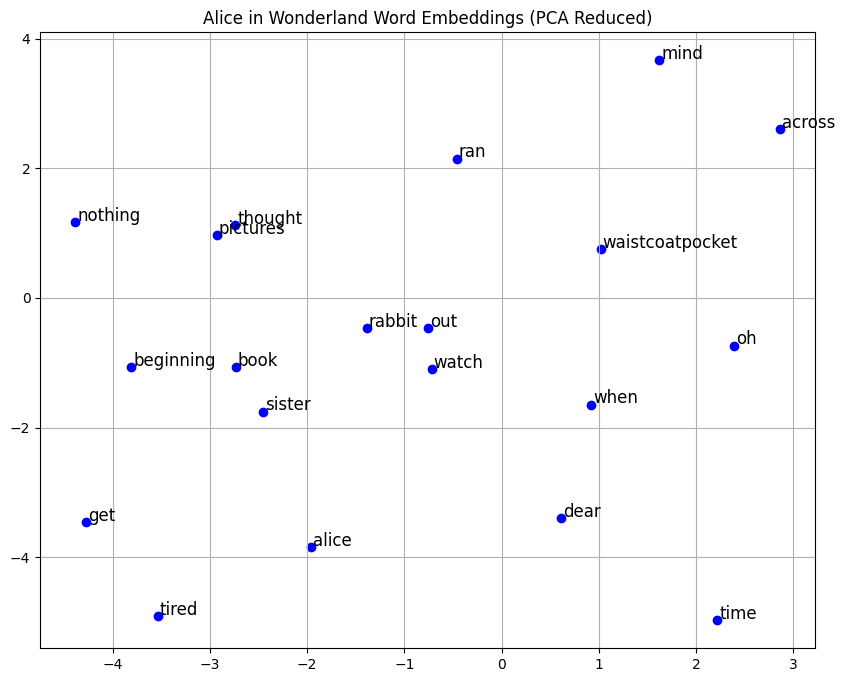

与 'alice' 最接近的词: [('reading', 0.58367807), ('conversations', 0.5331661), ('flashed', 0.5069164)]
与 'rabbit' 最接近的词: [('white', 0.53030646), ('sitting', 0.47532138), ('out', 0.46376616)]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA  # 使用 sklearn 进行降维

# ============================================================
# 1. 提取并降维词向量
# ============================================================
# 从模型中提取所有词的向量
# .weight 是 Embedding 层的权重矩阵，形状: (vocab_size, embedding_dim)
# .detach() 从计算图中分离，避免梯度计算
# .numpy() 转换为 NumPy 数组，方便后续处理
all_embeddings = model.embeddings.weight.detach().numpy()

# 使用 PCA（主成分分析）进行降维
# 目的：将 10 维向量压缩到 2 维，便于在平面上可视化
# PCA 会找到数据方差最大的两个方向作为新的坐标轴
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# ============================================================
# 2. 选择高频词进行可视化
# ============================================================
# 统计每个词的出现频率
word_counts = Counter(processed_words)

# 选择出现频率最高的 20 个词
# 原因：词太多会导致图表混乱，只展示代表性的词
top_words = [w for w, c in word_counts.most_common(20)]

# ============================================================
# 3. 绘制词向量分布图
# ============================================================
plt.figure(figsize=(10, 8))

for word in top_words:
    # 获取该词在词表中的索引
    idx = word_to_idx[word]
    
    # 获取该词降维后的 2D 坐标
    x, y = embeddings_2d[idx]
    
    # 绘制散点
    plt.scatter(x, y, color='blue')
    
    # 在散点旁边标注词
    # x+0.02, y+0.02 是偏移量，避免文字覆盖散点
    plt.text(x+0.02, y+0.02, word, fontsize=12)

plt.title("Alice in Wonderland Word Embeddings (PCA Reduced)")
plt.grid(True)
plt.show()

# ============================================================
# 4. 实现词相似度查询功能
# ============================================================
def find_similar_words(target_word, top_k=3):
    """查找与目标词最相似的词
    
    相似度计算：使用余弦相似度
    公式: cos(θ) = (A · B) / (||A|| × ||B||)
    其中 A·B 是向量点积，||A|| 是向量的模（长度）
    
    余弦相似度范围: [-1, 1]
    - 1: 完全相同方向（最相似）
    - 0: 正交（无关）
    - -1: 完全相反方向
    
    参数:
        target_word: 目标词
        top_k: 返回最相似的前 k 个词
        
    返回:
        相似词列表，每个元素是 (词, 相似度) 元组
    """
    # 检查词是否在词表中
    if target_word not in word_to_idx:
        return "Word not in vocabulary!"
    
    # 获取目标词的向量
    target_vec = all_embeddings[word_to_idx[target_word]]
    
    # 存储每个词与目标词的相似度
    similarities = {}
    
    # 遍历词表中的所有词
    for word, idx in word_to_idx.items():
        # 跳过目标词自己
        if word == target_word: 
            continue
            
        # 获取当前词的向量
        vec = all_embeddings[idx]
        
        # 计算余弦相似度
        # 分子：向量点积
        # 分母：两个向量的模的乘积
        sim = vec.dot(target_vec) / (np.linalg.norm(vec) * np.linalg.norm(target_vec))
        similarities[word] = sim
    
    # 按相似度降序排序
    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    
    # 返回前 k 个最相似的词
    return sorted_words[:top_k]

# ============================================================
# 5. 测试词相似度查询
# ============================================================
# 查找与 'alice' 最接近的词
# 预期：可能是 'rabbit', 'thought' 等在文本中与 alice 经常一起出现的词
print("与 'alice' 最接近的词:", find_similar_words('alice'))

# 查找与 'rabbit' 最接近的词
# 预期：可能是 'white', 'alice' 等相关词
print("与 'rabbit' 最接近的词:", find_similar_words('rabbit'))
